In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv("solar_system.csv", index_col=0)
df

print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nColumn names:")
print(df.columns)

print("\nRow names:")
print(df.index)

Shape: (20, 10)
Rows: 20
Columns: 10

First 5 rows:
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  

Last 5 rows:
                        Mercury Venus Earth Moon  M

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv("solar_system.csv", index_col=0)
df

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8


In [7]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nColumn names:")
print(df.columns)

print("\nRow names:")
print(df.index)

Shape: (20, 10)
Rows: 20
Columns: 10

First 5 rows:
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  

Last 5 rows:
                        Mercury Venus Earth Moon  M

In [9]:
df.index = df.index.str.strip().str.lower()
print(df.index)

Index(['mass (10^24kg)', 'diameter (km)', 'density (kg/m^3)',
       'gravity (m/s^2)', 'escape velocity (km/s)', 'rotation period (hours)',
       'length of day (hours)', 'distance from sun (10^6 km)',
       'perihelion (10^6 km)', 'aphelion (10^6 km)', 'orbital period (days)',
       'orbital velocity (km/s)', 'orbital inclination (deg)',
       'orbital eccentricity', 'obliquity to orbit (deg)',
       'mean temperature (c)', 'surface pressure (bars)', 'number of moons',
       'ring system?', 'global magnetic field?'],
      dtype='object', name='Attribute')


In [11]:
for i in df.index:
    print(repr(i))

'mass (10^24kg)'
'diameter (km)'
'density (kg/m^3)'
'gravity (m/s^2)'
'escape velocity (km/s)'
'rotation period (hours)'
'length of day (hours)'
'distance from sun (10^6 km)'
'perihelion (10^6 km)'
'aphelion (10^6 km)'
'orbital period (days)'
'orbital velocity (km/s)'
'orbital inclination (deg)'
'orbital eccentricity'
'obliquity to orbit (deg)'
'mean temperature (c)'
'surface pressure (bars)'
'number of moons'
'ring system?'
'global magnetic field?'


In [12]:
# Find the correct rows automatically
orbital_period = df[df.index.str.contains("orbital", case=False)].iloc[0].astype(float)
perihelion = df[df.index.str.contains("perihelion", case=False)].iloc[0].astype(float)
aphelion = df[df.index.str.contains("aphelion", case=False)].iloc[0].astype(float)

print("Orbital period:")
print(orbital_period)

print("\nPerihelion:")
print(perihelion)

print("\nAphelion:")
print(aphelion)

Orbital period:
Mercury       88.0
Venus        224.7
Earth        365.2
Moon          27.3
Mars         687.0
Jupiter     4331.0
Saturn     10747.0
Uranus     30589.0
Neptune    59800.0
Pluto      90560.0
Name: orbital period (days), dtype: float64

Perihelion:
Mercury      46.000
Venus       107.500
Earth       147.100
Moon          0.363
Mars        206.700
Jupiter     740.600
Saturn     1357.600
Uranus     2732.700
Neptune    4471.100
Pluto      4436.800
Name: perihelion (10^6 km), dtype: float64

Aphelion:
Mercury      69.800
Venus       108.900
Earth       152.100
Moon          0.406
Mars        249.300
Jupiter     816.400
Saturn     1506.500
Uranus     3001.400
Neptune    4558.900
Pluto      7375.900
Name: aphelion (10^6 km), dtype: float64



Semi-major axis:
Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64

New shape: (21, 10)
Rows: 21
Columns: 10


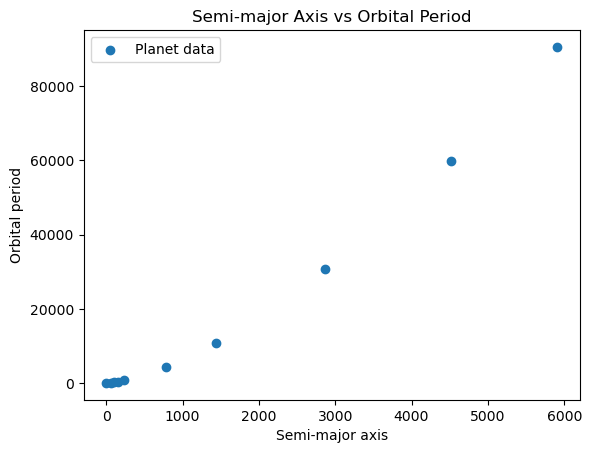

Best-fit parameter m: 0.19879981918623565
Fit: T = 0.20 * a^1.5
Chi-squared: 371490.35


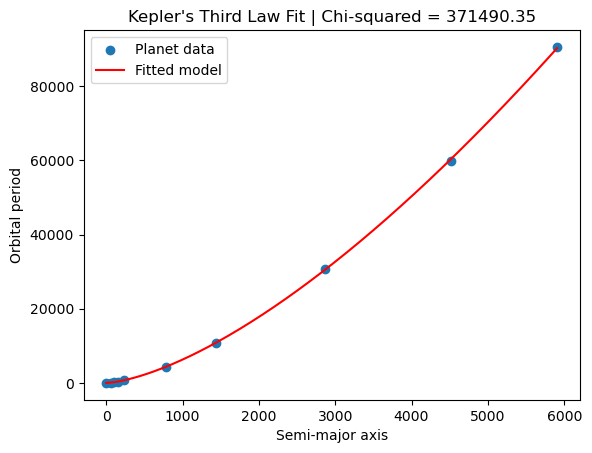

In [13]:
# Compute semi-major axis
semi_major_axis = (perihelion + aphelion) / 2

print("\nSemi-major axis:")
print(semi_major_axis)

# Add semi-major axis as a new row to the DataFrame
df.loc["semi_major_axis"] = semi_major_axis

print("\nNew shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df

# Scatter plot
plt.scatter(semi_major_axis, orbital_period, label="Planet data")

plt.xlabel("Semi-major axis")
plt.ylabel("Orbital period")
plt.title("Semi-major Axis vs Orbital Period")
plt.legend()
plt.show()

# Define Kepler's Third Law model
def keplers_third_law(a, m):
    return m * a ** 1.5

# Fit the model
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)
m_fit = popt[0]

print("Best-fit parameter m:", m_fit)
print(f"Fit: T = {m_fit:.2f} * a^1.5")

# Calculate chi-squared
predicted_period = keplers_third_law(semi_major_axis, m_fit)
residuals = orbital_period - predicted_period
chi2 = np.sum(residuals**2)

print(f"Chi-squared: {chi2:.2f}")

# Plot data and fitted model
a_fit = np.linspace(semi_major_axis.min(), semi_major_axis.max(), 200)
T_fit = keplers_third_law(a_fit, m_fit)

plt.scatter(semi_major_axis, orbital_period, label="Planet data")
plt.plot(a_fit, T_fit, color="red", label="Fitted model")

plt.xlabel("Semi-major axis")
plt.ylabel("Orbital period")
plt.title(f"Kepler's Third Law Fit | Chi-squared = {chi2:.2f}")
plt.legend()
plt.show()

# Save the new DataFrame
df.to_csv("kepler.csv")